In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.6 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import pandas as pd

# Upload dataset
uploaded = files.upload()

# Example (only if using CSV dataset)
# df = pd.read_csv("your_dataset.csv")
# print(df.head())

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Initial Shape:", x_train.shape)
print("Missing Values: None (Image dataset)")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Initial Shape: (60000, 28, 28)
Missing Values: None (Image dataset)


In [ ]:
# Normalize
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Data normalized")

Data normalized


In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9163 - loss: 0.2907 - val_accuracy: 0.9570 - val_loss: 0.1507
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9620 - loss: 0.1264 - val_accuracy: 0.9657 - val_loss: 0.1209
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9750 - loss: 0.0856 - val_accuracy: 0.9719 - val_loss: 0.0942
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9808 - loss: 0.0640 - val_accuracy: 0.9730 - val_loss: 0.0901
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9850 - loss: 0.0482 - val_accuracy: 0.9743 - val_loss: 0.0905
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9883 - loss: 0.0386 - val_accuracy: 0.9758 - val_loss: 0.0866
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9913 - loss: 0.0295 - val_accuracy: 0.9752 - val_loss: 0.0847
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9928 - loss: 0.0235 - 

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0794
Test Accuracy: 0.977400004863739


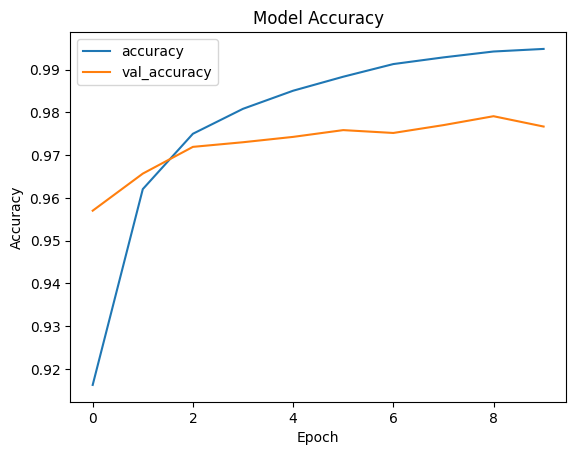

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [ ]:
def model_builder(hp):
    model = keras.Sequential()

    model.add(keras.layers.Flatten(input_shape=(28,28)))

    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    model.add(keras.layers.Dense(units=hp_units, activation='relu'))

    model.add(keras.layers.Dense(10, activation='softmax'))

    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
tuner = kt.Hyperband(
    model_builder,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='my_dir',
    project_name='ann_tuning'
)

tuner.search(
    x_train, y_train,1
    epochs=10,
    validation_split=0.2
)

Trial 30 Complete [00h 01m 04s]
val_accuracy: 0.9602500200271606

Best val_accuracy So Far: 0.9799166917800903
Total elapsed time: 00h 18m 44s


In [ ]:
best_hps = tuner.get_best_hyperparameters(1)[0]

model = tuner.hypermodel.build(best_hps)

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9316 - loss: 0.2318 - val_accuracy: 0.9625 - val_loss: 0.1258
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9719 - loss: 0.0942 - val_accuracy: 0.9715 - val_loss: 0.0954
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9812 - loss: 0.0600 - val_accuracy: 0.9733 - val_loss: 0.0934
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9874 - loss: 0.0412 - val_accuracy: 0.9756 - val_loss: 0.0826
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9904 - loss: 0.0310 - val_accuracy: 0.9753 - val_loss: 0.0876
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9930 - loss: 0.0224 - val_accuracy: 0.9760 - val_loss: 0.0887
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9945 - loss: 0.0176 - val_accuracy: 0.9796 - val_loss: 0.0754
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9954 - loss: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


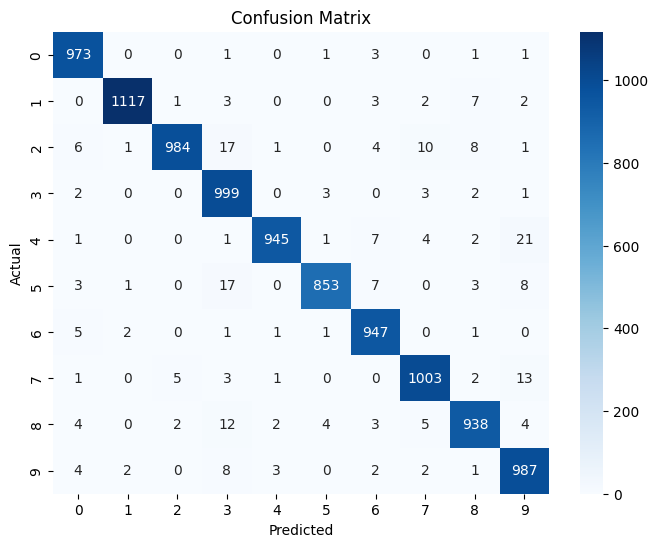

In [ ]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

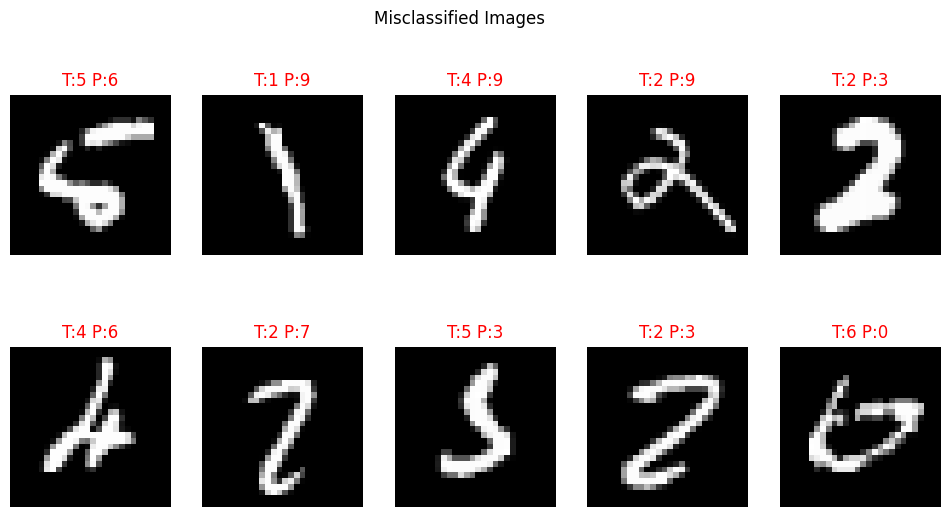

In [ ]:
errors = (y_pred_classes != y_test)

x_errors = x_test[errors]
y_errors = y_test[errors]
y_pred_errors = y_pred_classes[errors]

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_errors[i], cmap='gray')
    plt.title(f"T:{y_errors[i]} P:{y_pred_errors[i]}", color='red')
    plt.axis('off')

plt.suptitle("Misclassified Images")
plt.show()